In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import os
import torch

from datasets import load_dataset
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
    DataCollatorWithPadding
)
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score

In [2]:
RANDOM_SEED = 42
torch.manual_seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

In [3]:
device = "cuda" if torch.cuda.is_available() else "cpu"
if torch.backends.mps.is_available():
    device = "mps"

print(f"System status: Ready. Device: {device}")

System status: Ready. Device: cuda


In [4]:
MODEL_NAME = "deepvk/RuModernBERT-base"

In [5]:
TRAIN_PATH = '/content/drive/MyDrive/Colab Notebooks/Third semester/Fine-Tuning/RuBert-Data/rusentitweet_train.csv'
TEST_PATH = '/content/drive/MyDrive/Colab Notebooks/Third semester/Fine-Tuning/RuBert-Data/rusentitweet_test.csv'

In [6]:
print(f"Путь: {TRAIN_PATH}")

try:
    dataset = load_dataset('csv', data_files={'train': TRAIN_PATH, 'test': TEST_PATH})

    label2id = {
        "neutral": 0,
        "positive": 1,
        "negative": 2,
        "speech": 3,
        "skip": 4
    }
    id2label = {v: k for k, v in label2id.items()}

    def encode_labels(batch):
        new_labels = []
        for item in batch['label']:
            if isinstance(item, str):
                clean_item = item.lower().strip()
                if clean_item in label2id:
                    new_labels.append(label2id[clean_item])
                else:
                    new_labels.append(4)

            elif isinstance(item, (int, float)):
                new_labels.append(int(item))

            elif isinstance(item, list):
                val = item[0]
                if isinstance(val, str) and val.lower().strip() in label2id:
                     new_labels.append(label2id[val.lower().strip()])
                else:
                     new_labels.append(int(val))
            else:
                new_labels.append(4)

        batch['label'] = new_labels
        return batch

    print("Encoding...")
    dataset = dataset.map(encode_labels, batched=True)

    print("Разделение на train/test...")
    split = dataset['train'].train_test_split(test_size=0.1, seed=RANDOM_SEED)
    dataset['train'] = split['train']
    dataset['validation'] = split['test']

    print("Датасет загружен и готов")
    print("Пример Label Enconding:", dataset['train'][0]['label'])
    print("Структура:", dataset)

except Exception as e:
    print(f"Ошибка при обработке: {e}")

Путь: /content/drive/MyDrive/Colab Notebooks/Third semester/Fine-Tuning/RuBert-Data/rusentitweet_train.csv


Generating train split: 0 examples [00:00, ? examples/s]

Generating test split: 0 examples [00:00, ? examples/s]

Encoding...


Map:   0%|          | 0/10713 [00:00<?, ? examples/s]

Map:   0%|          | 0/2679 [00:00<?, ? examples/s]

Разделение на train/test...
Датасет загружен и готов
Пример Label Enconding: 2
Структура: DatasetDict({
    train: Dataset({
        features: ['text', 'label', 'id'],
        num_rows: 9641
    })
    test: Dataset({
        features: ['text', 'label', 'id'],
        num_rows: 2679
    })
    validation: Dataset({
        features: ['text', 'label', 'id'],
        num_rows: 1072
    })
})


In [7]:
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

def tokenize_function(examples):
    return tokenizer(
        examples["text"],
        padding=False,
        truncation=True,
        max_length=128
    )

tokenized_datasets = dataset.map(
    tokenize_function,
    batched=True,
    remove_columns=['text']
)

data_collator = DataCollatorWithPadding(tokenizer=tokenizer)
print("Tokenization complete.")
print("Feature keys:", tokenized_datasets['train'].features.keys())

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/837 [00:00<?, ?B/s]

Map:   0%|          | 0/9641 [00:00<?, ? examples/s]

Map:   0%|          | 0/2679 [00:00<?, ? examples/s]

Map:   0%|          | 0/1072 [00:00<?, ? examples/s]

Tokenization complete.
Feature keys: dict_keys(['label', 'id', 'input_ids', 'attention_mask'])


In [8]:
def compute_metrics(eval_pred):
    predictions, labels = eval_pred
    predictions = np.argmax(predictions, axis=1)
    f1 = f1_score(labels, predictions, average="weighted")
    return {"accuracy": accuracy_score(labels, predictions), "f1": f1}

model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=len(id2label),
    id2label=id2label,
    label2id=label2id
).to(device)

config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/599M [00:00<?, ?B/s]

Some weights of ModernBertForSequenceClassification were not initialized from the model checkpoint at deepvk/RuModernBERT-base and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [9]:
training_args = TrainingArguments(
    output_dir="./rumodernbert_final",
    eval_strategy="epoch",
    save_strategy="epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=32,
    per_device_eval_batch_size=32,
    num_train_epochs=4,
    weight_decay=0.01,
    load_best_model_at_end=True,
    metric_for_best_model="f1",
    save_total_limit=2,
    seed=RANDOM_SEED,
    logging_strategy="steps",
    logging_steps=20,
    report_to="none"
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_datasets["train"],
    eval_dataset=tokenized_datasets["validation"],
    tokenizer=tokenizer,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
)

print("Запуск обучения: ")
trainer.train()

/tmp/ipython-input-3785751979.py:19: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(
The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'eos_token_id': None, 'bos_token_id': None}.


Запуск обучения: 


Epoch,Training Loss,Validation Loss,Accuracy,F1
1,0.705800,0.750425,0.711754,0.701306
2,0.524800,0.725883,0.729478,0.724910
3,0.199700,0.976700,0.698694,0.702386
4,0.031100,1.608147,0.721082,0.721008


TrainOutput(global_step=1208, training_loss=0.4509569477067878, metrics={'train_runtime': 666.5286, 'train_samples_per_second': 57.858, 'train_steps_per_second': 1.812, 'total_flos': 1582950285592860.0, 'train_loss': 0.4509569477067878, 'epoch': 4.0})

In [10]:
model.save_pretrained("./rumodernbert_final")
tokenizer.save_pretrained("./rumodernbert_final")
print("Успешно созранено.")

Успешно созранено.


In [11]:
sns.set_theme(style="whitegrid", context="paper", font_scale=1.4)
plt.rcParams['figure.dpi'] = 300
plt.rcParams['font.family'] = 'serif'

In [12]:
history = trainer.state.log_history
df = pd.DataFrame(history)

In [13]:
train_loss_data = df[df['loss'].notnull()][['epoch', 'loss']].copy()
eval_data = df[df['eval_loss'].notnull()][['epoch', 'eval_loss', 'eval_f1', 'eval_accuracy']]

In [14]:
train_loss_data['loss_smooth'] = train_loss_data['loss'].ewm(span=10).mean()

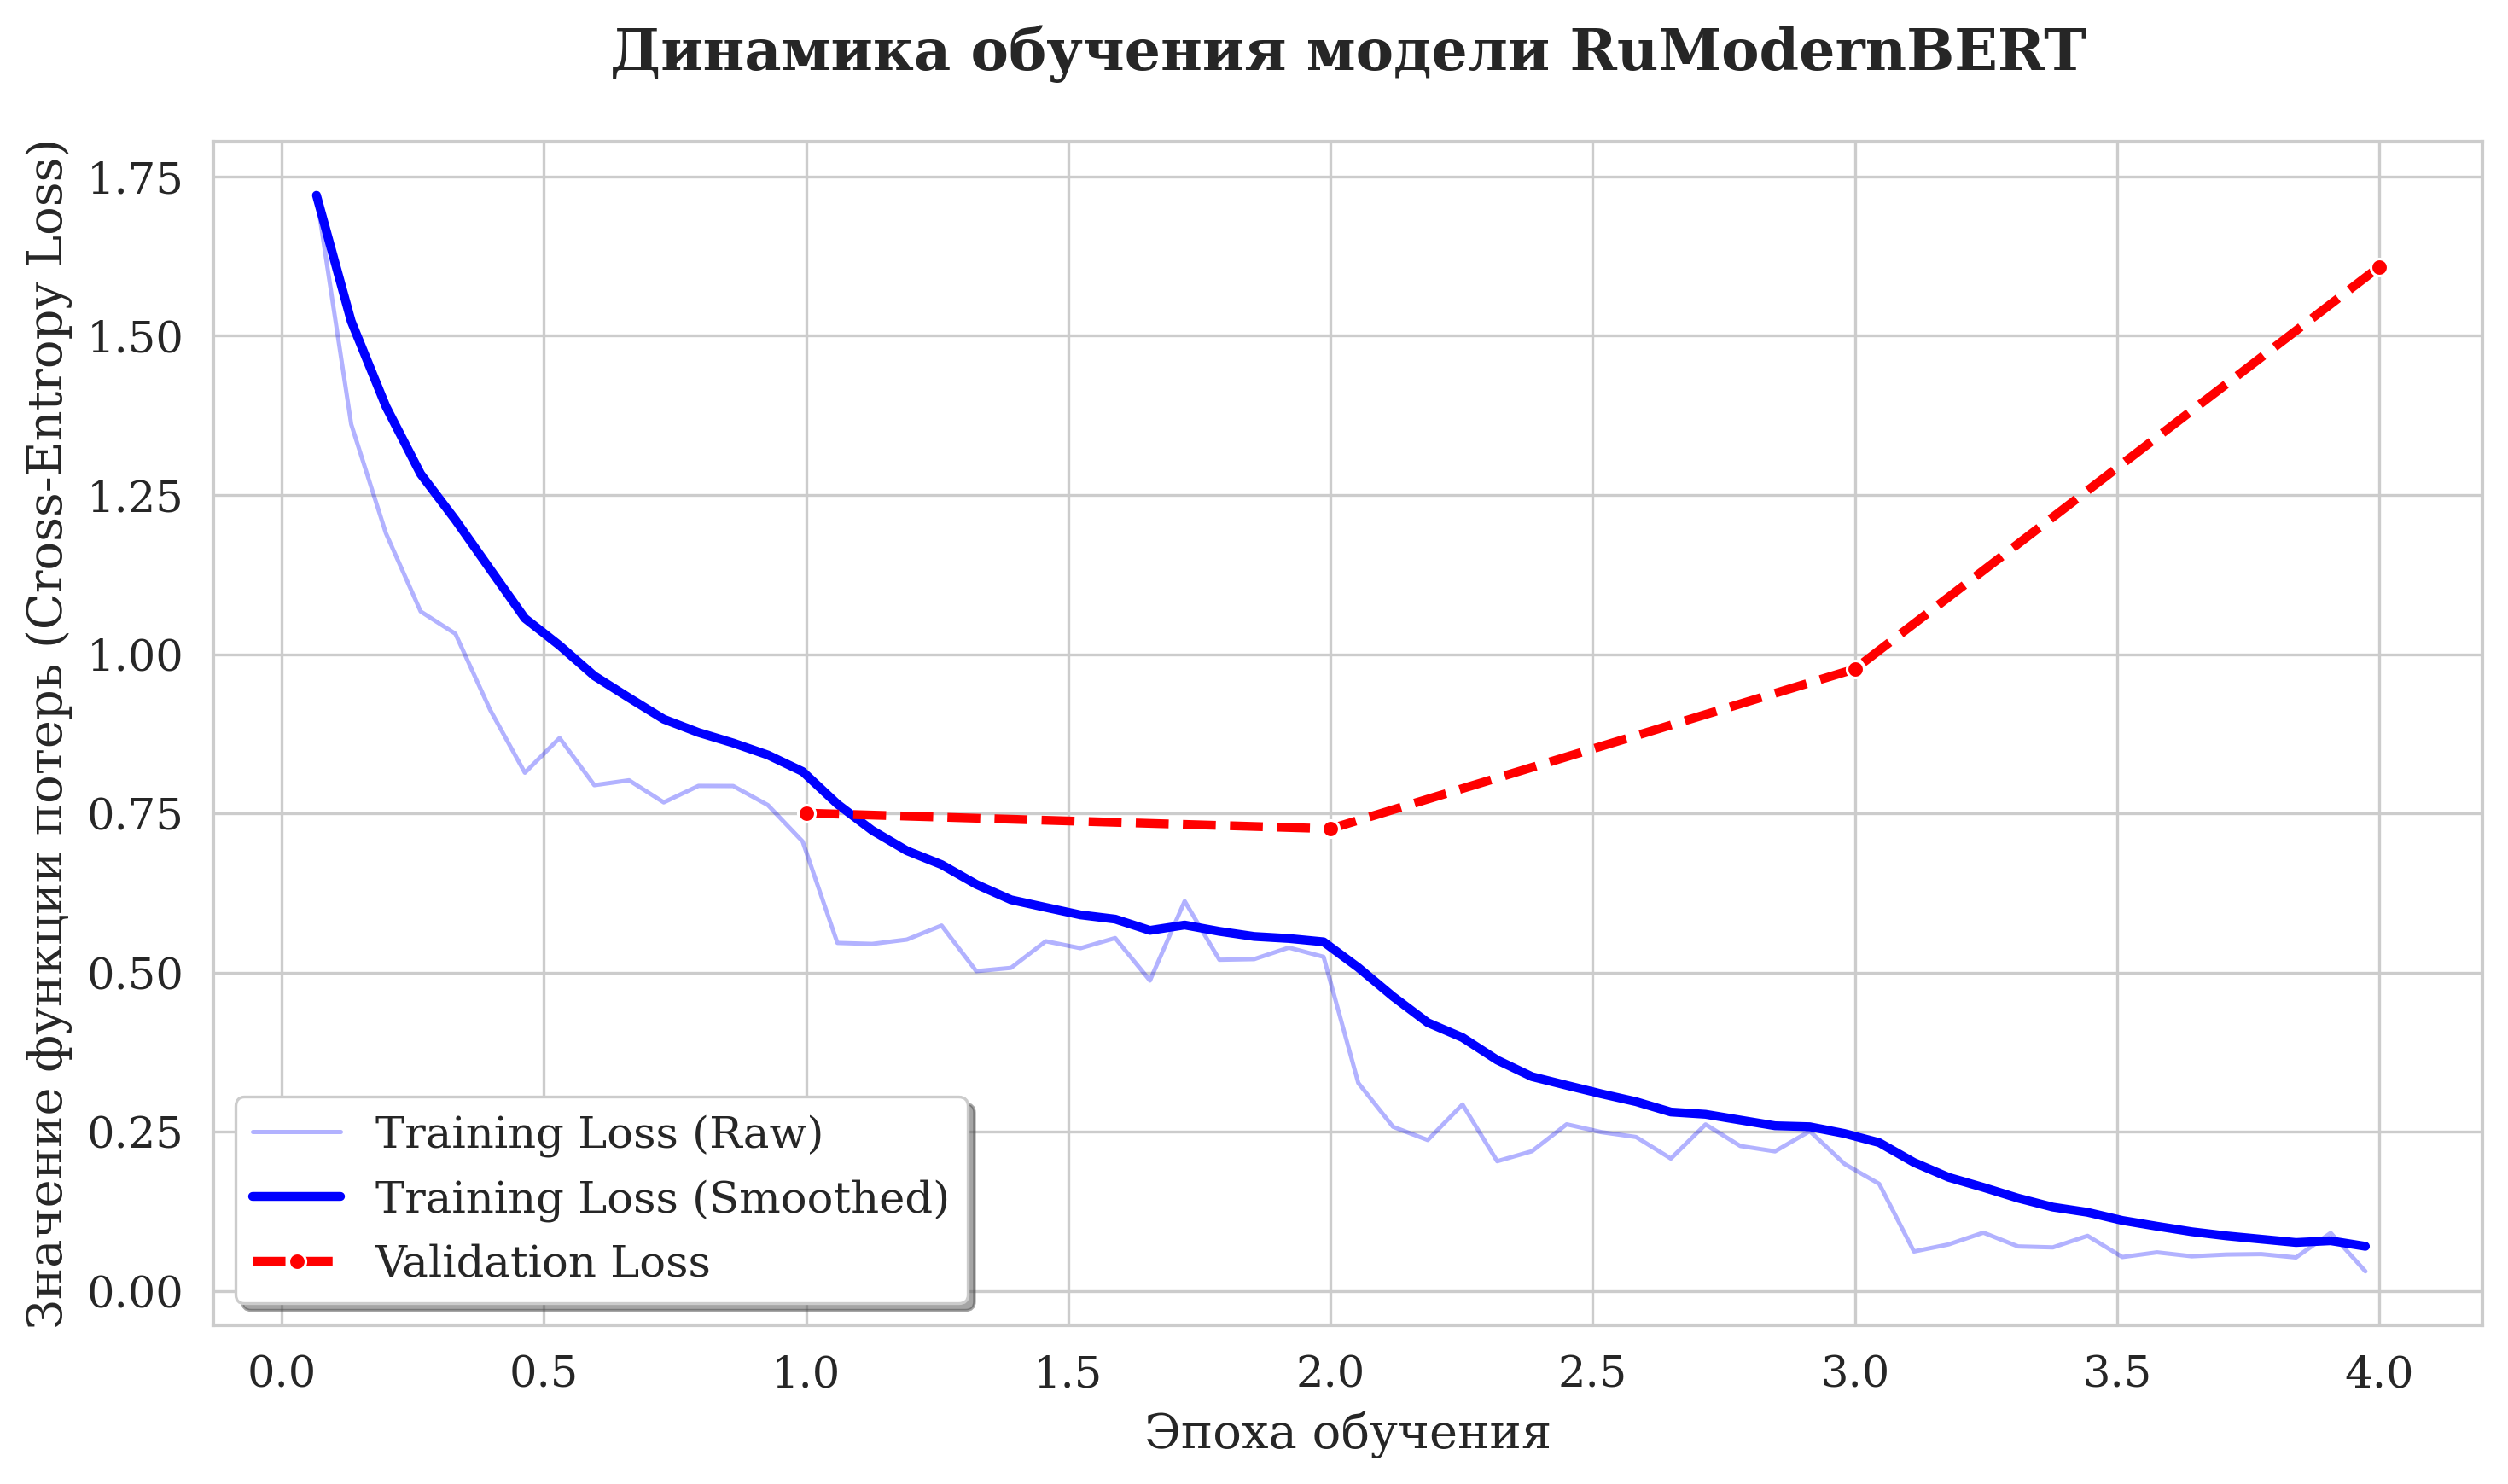

In [15]:
plt.figure(figsize=(10, 6))
sns.lineplot(data=train_loss_data, x='epoch', y='loss', alpha=0.3, color='blue', label='Training Loss (Raw)')
sns.lineplot(data=train_loss_data, x='epoch', y='loss_smooth', color='blue', linewidth=2.5, label='Training Loss (Smoothed)')
sns.lineplot(data=eval_data, x='epoch', y='eval_loss', color='red', linestyle='--', linewidth=2.5, marker='o', label='Validation Loss')

plt.title('Динамика обучения модели RuModernBERT', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Эпоха обучения')
plt.ylabel('Значение функции потерь (Cross-Entropy Loss)')
plt.legend(frameon=True, shadow=True)
plt.tight_layout()
plt.savefig('thesis_loss_dynamics.png')
plt.show()

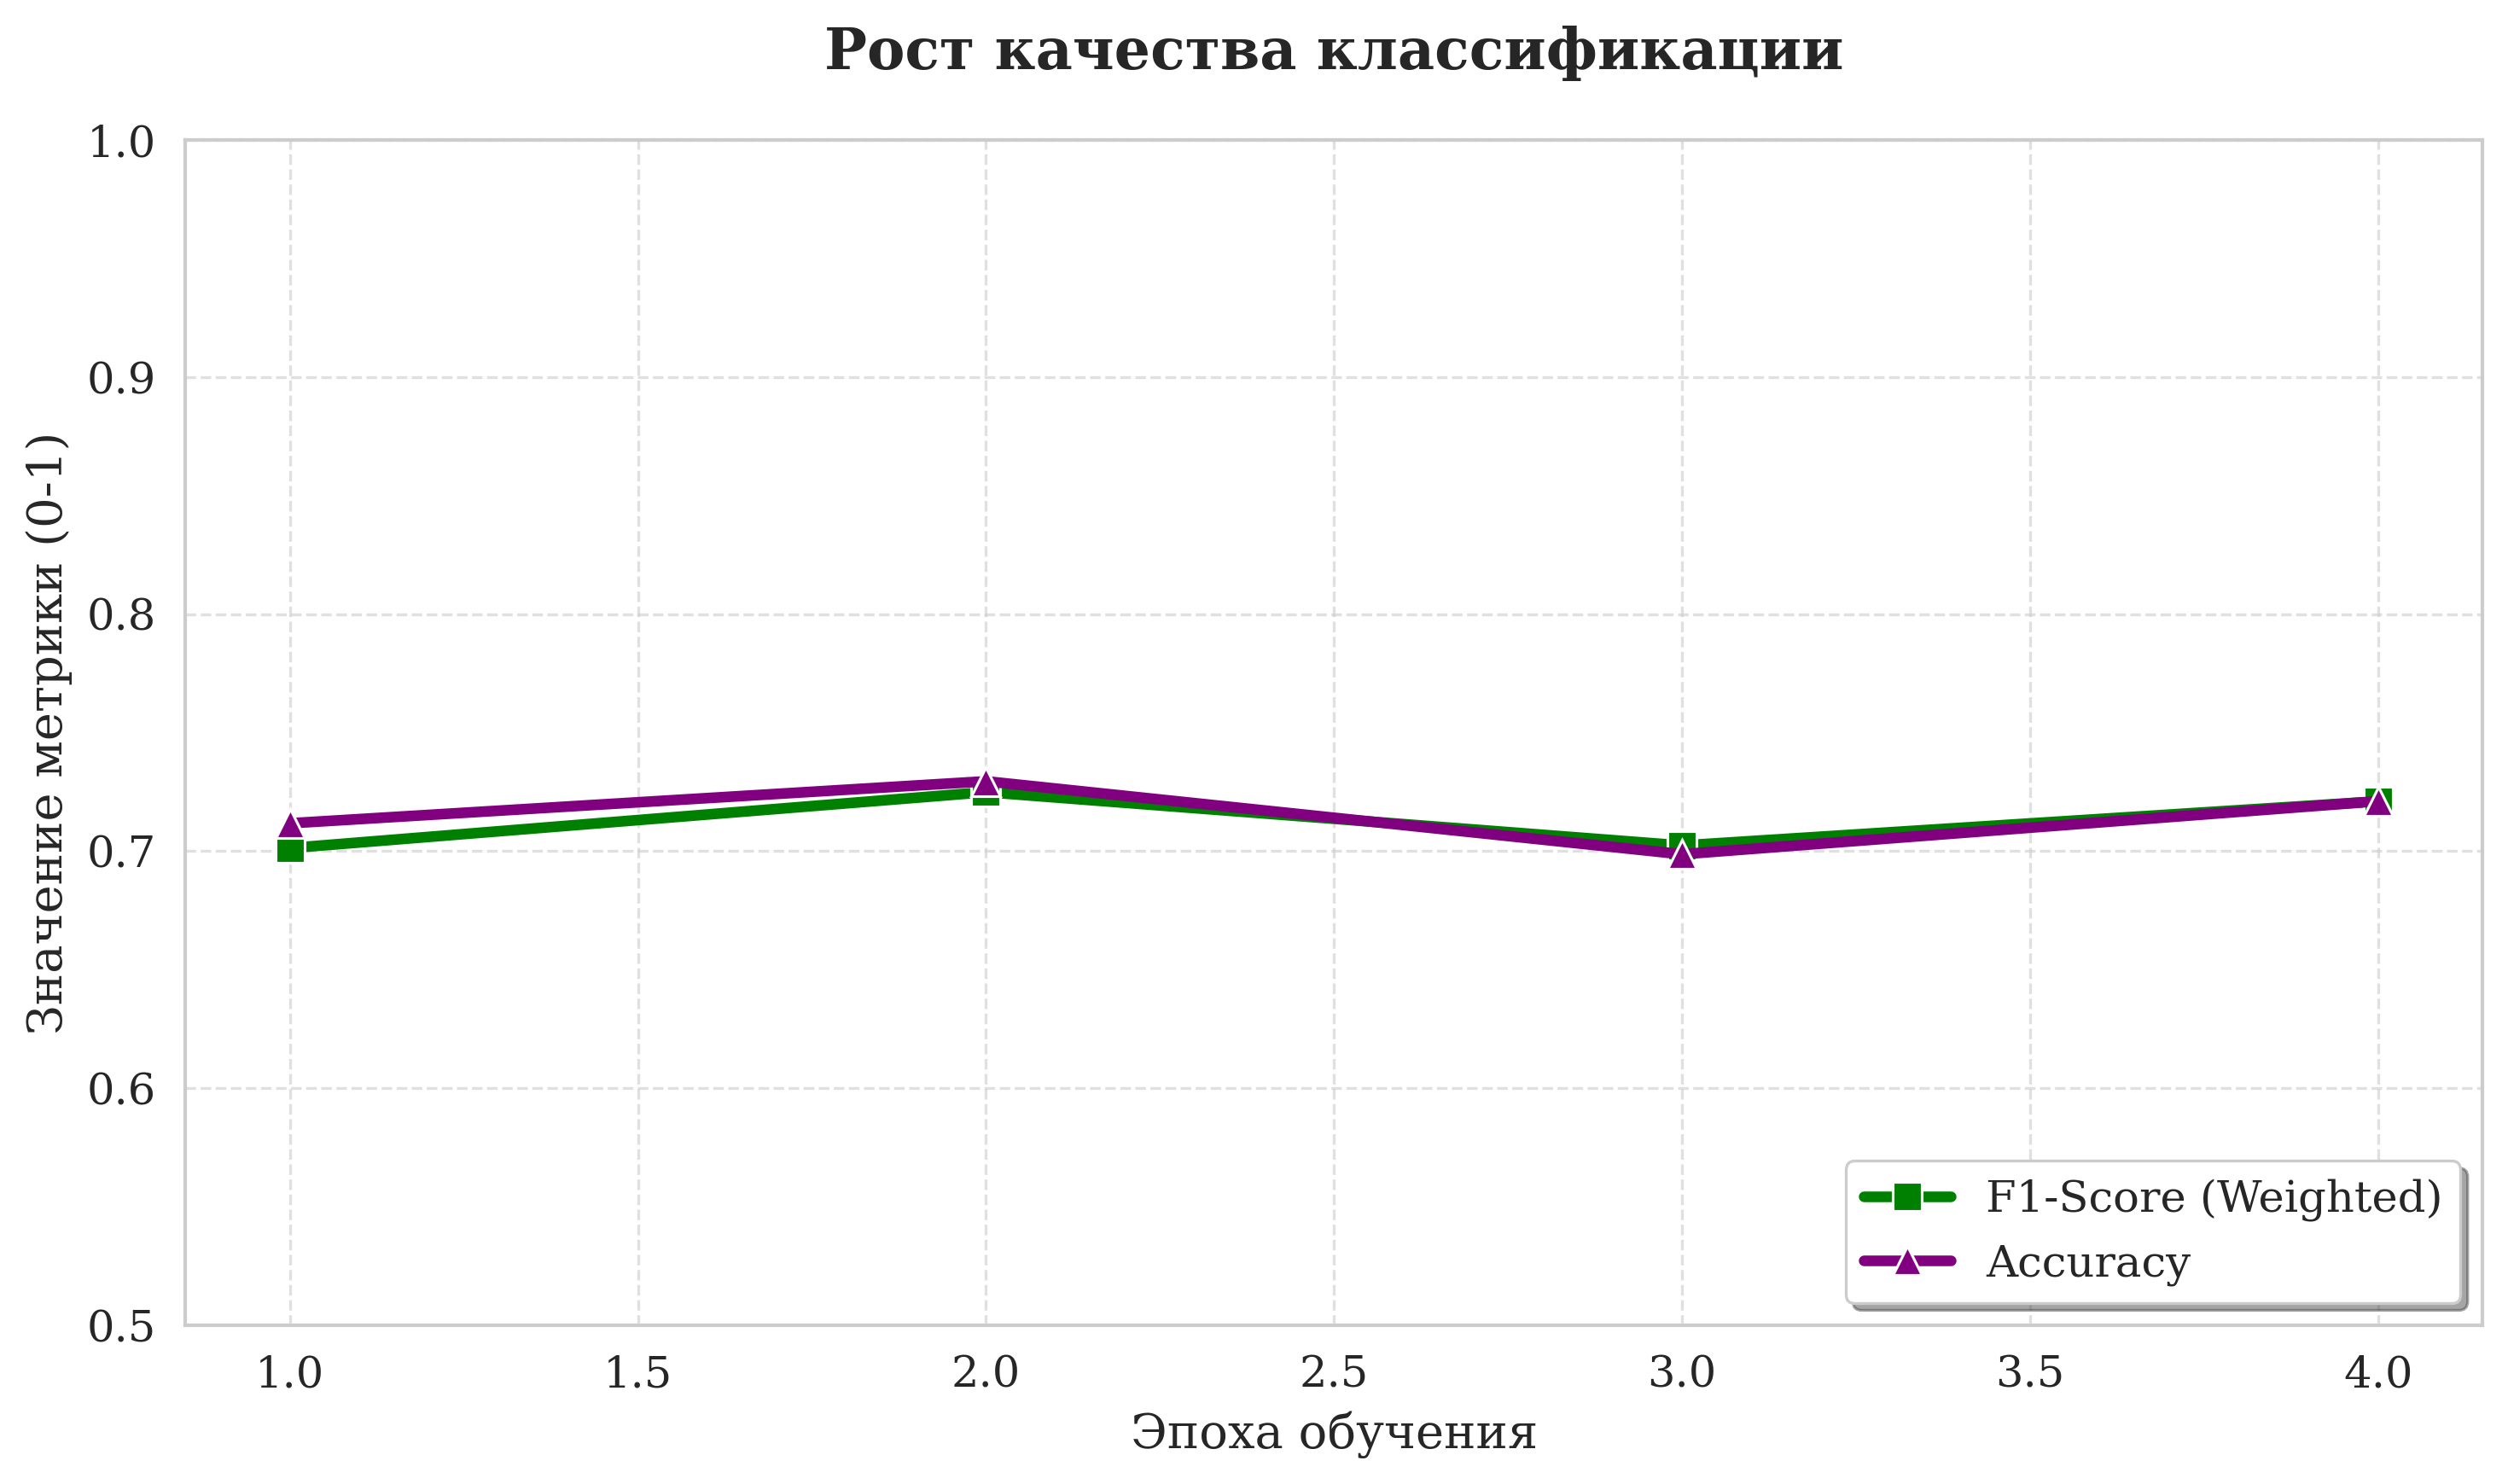

In [16]:
# --- График 2: Метрики качества ---
plt.figure(figsize=(10, 6))

sns.lineplot(data=eval_data, x='epoch', y='eval_f1', label='F1-Score (Weighted)', color='green', linewidth=3, marker='s', markersize=8)
sns.lineplot(data=eval_data, x='epoch', y='eval_accuracy', label='Accuracy', color='purple', linewidth=3, marker='^', markersize=8)

plt.title('Рост качества классификации', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Эпоха обучения')
plt.ylabel('Значение метрики (0-1)')
plt.ylim(0.5, 1.0)
plt.grid(True, which='both', linestyle='--', alpha=0.6)
plt.legend(frameon=True, shadow=True, loc='lower right')
plt.tight_layout()
plt.savefig('thesis_metrics_dynamics.png')
plt.show()

In [17]:
from sklearn.metrics import confusion_matrix

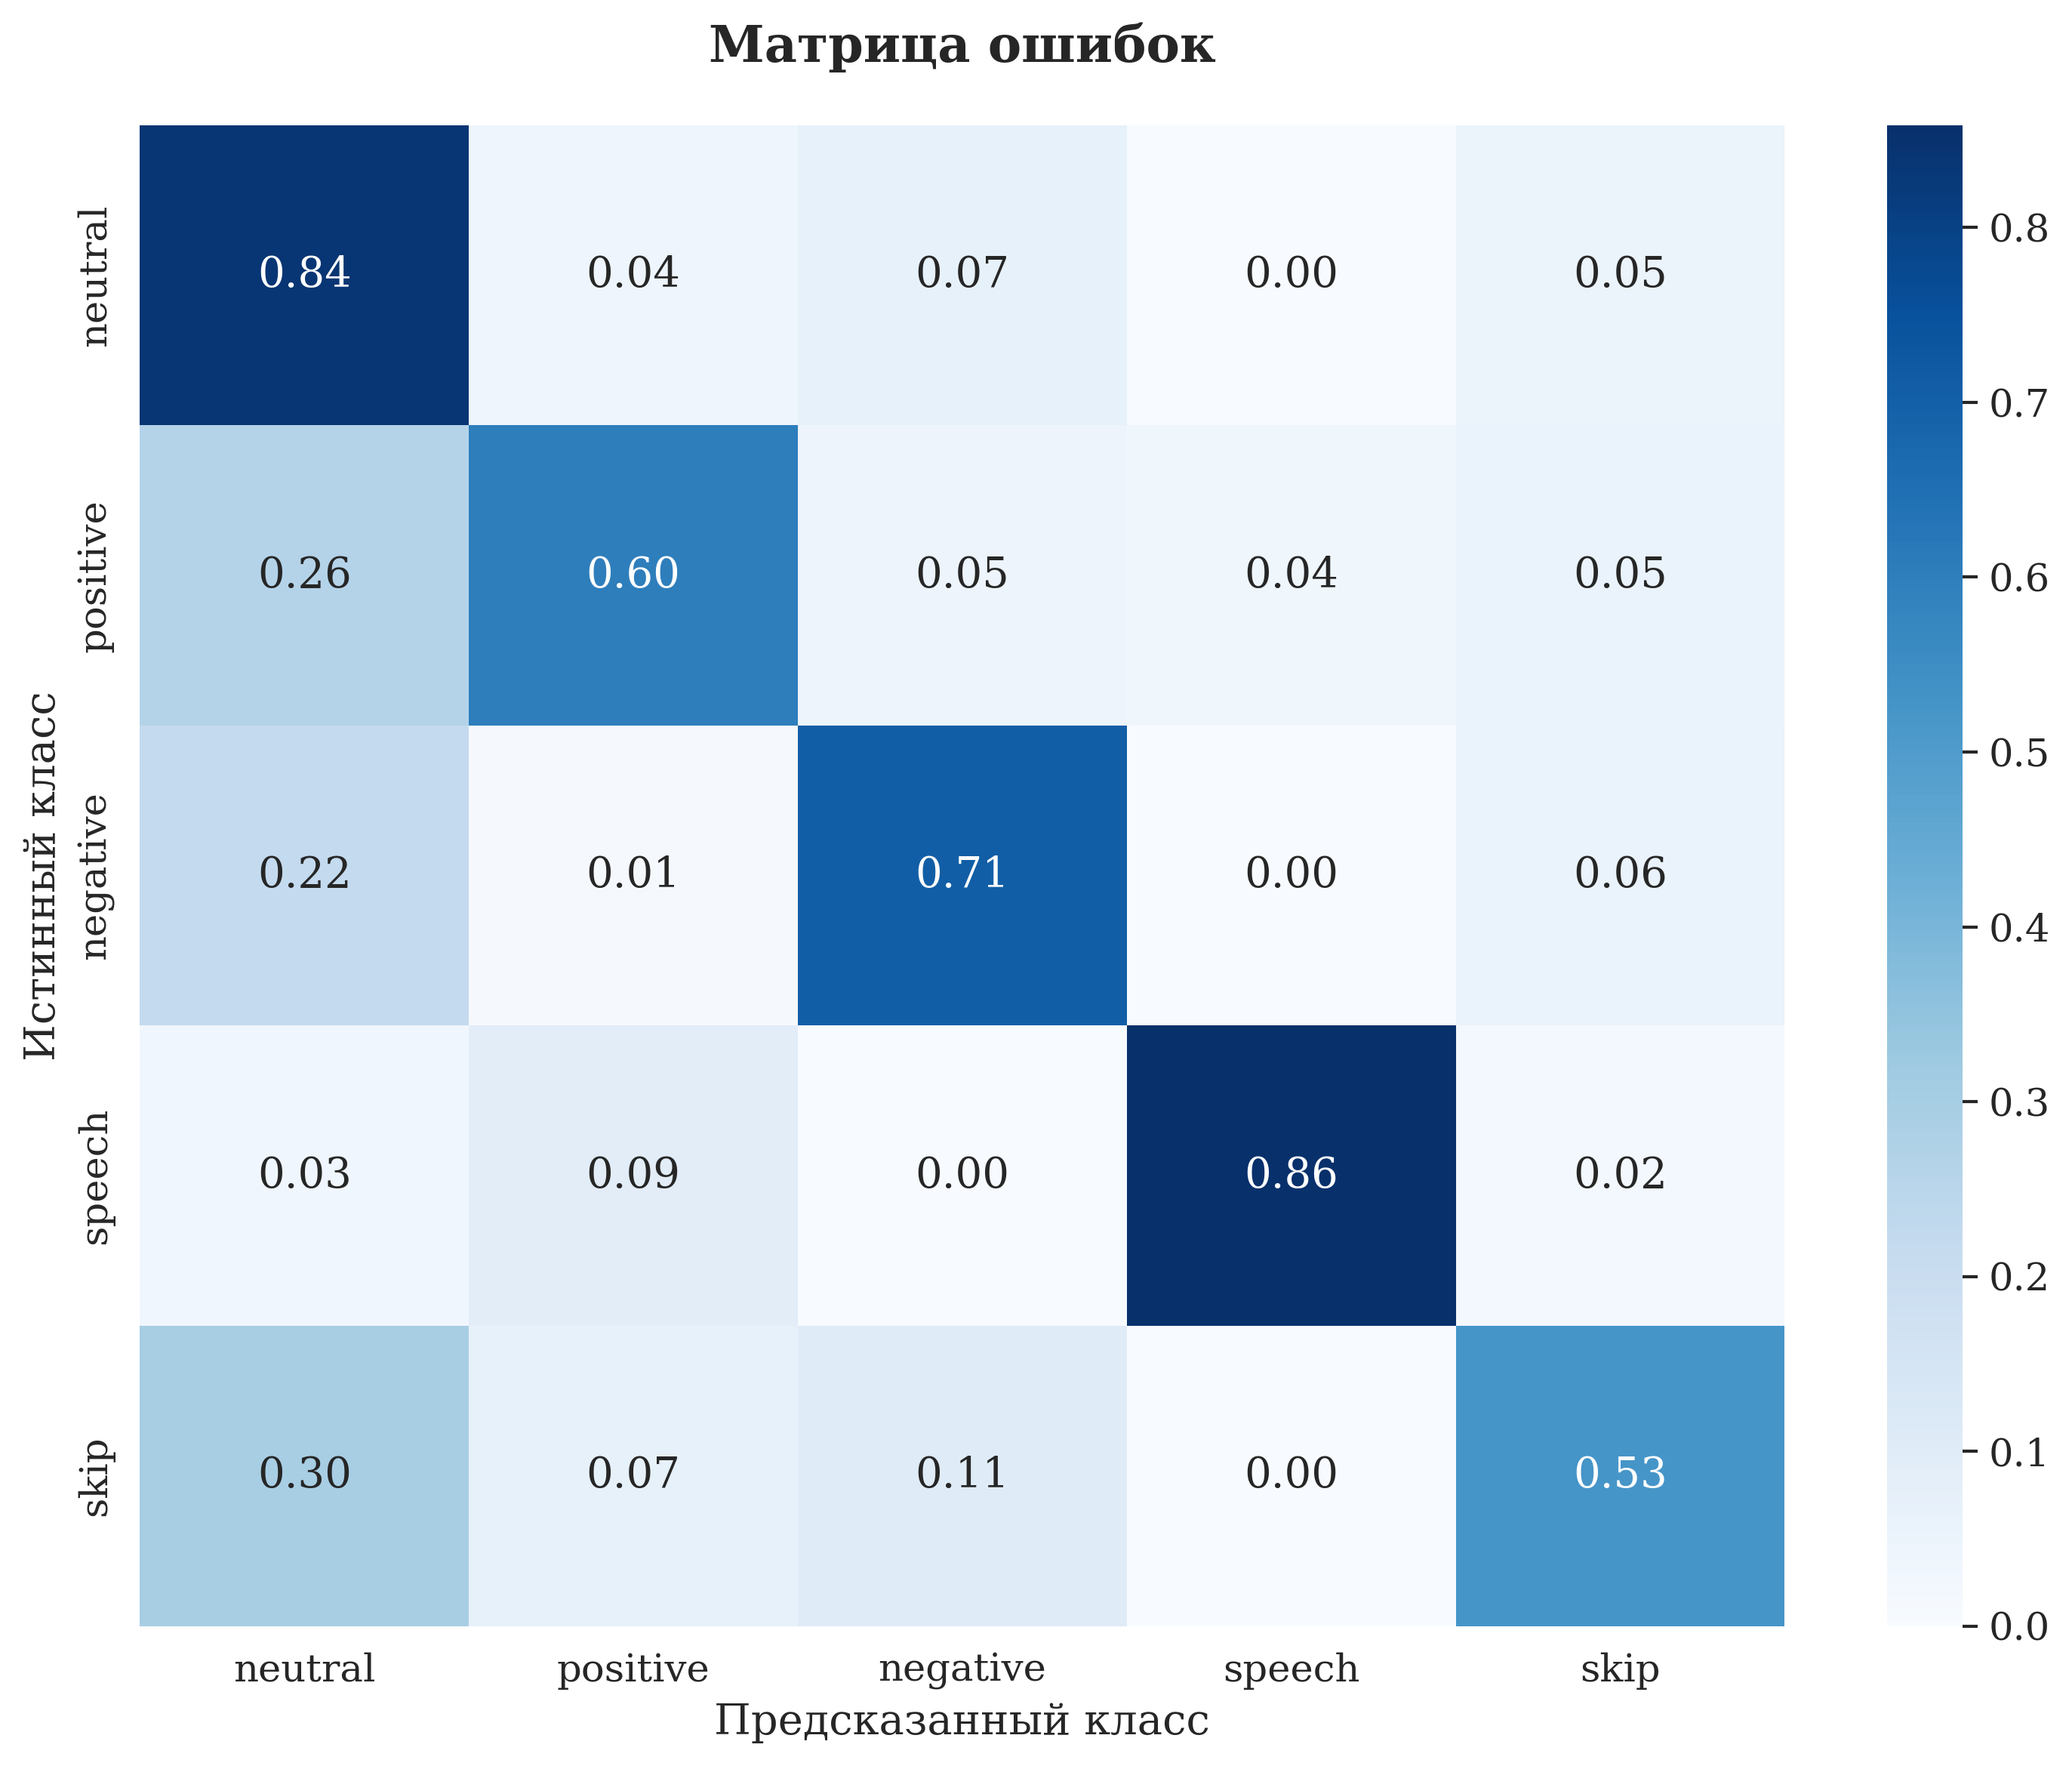

In [18]:
predictions_output = trainer.predict(tokenized_datasets["test"])
preds = np.argmax(predictions_output.predictions, axis=1)
labels = predictions_output.label_ids

cm = confusion_matrix(labels, preds)

cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

plt.figure(figsize=(10, 8))
sns.heatmap(
    cm_normalized,
    annot=True,
    fmt='.2f',
    cmap='Blues',
    xticklabels=[id2label[i] for i in range(len(id2label))],
    yticklabels=[id2label[i] for i in range(len(id2label))]
)

plt.title('Матрица ошибок', fontsize=16, fontweight='bold', pad=20)
plt.ylabel('Истинный класс')
plt.xlabel('Предсказанный класс')
plt.tight_layout()
plt.savefig('thesis_confusion_matrix.png')
plt.show()